 # 04 - Visualizations for Report

 **Goal:** Generate publication-quality figures for the LaTeX report.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

FIGURES_DIR = 'reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)


 ## Load Results

In [9]:
# Load pre-computed results if available
try:
    results_df = pd.read_csv(f'{FIGURES_DIR}/results_table.csv')
    print("Loaded results from CSV")
except:
    # Fallback data
    results_df = pd.DataFrame({
        'Model': ['Popularity', 'Item-KNN', 'MF', 'NeuMF (NCF)'],
        'P@5': [0.0023, 0.0000, 0.0011, 0.0034],
        'P@10': [0.0023, 0.0006, 0.0017, 0.0023],
        'R@5': [0.0043, 0.0000, 0.0011, 0.0071],
        'R@10': [0.0100, 0.0057, 0.0054, 0.0100],
        'NDCG@5': [0.0029, 0.0000, 0.0008, 0.0042],
        'NDCG@10': [0.0050, 0.0020, 0.0027, 0.0053],
        'Time (s)': [0.01, 0.5, 5.0, 8.0]
    })
    print("Using fallback results")

print(results_df)


Loaded results from CSV
         Model       P@5      P@10       R@5      R@10    NDCG@5   NDCG@10  \
0   Popularity  0.002286  0.002286  0.004286  0.010000  0.002867  0.005027   
1     Item-KNN  0.000000  0.000571  0.000000  0.005714  0.000000  0.002035   
2           MF  0.001143  0.002286  0.002857  0.014286  0.001355  0.005887   
3  NeuMF (NCF)  0.002286  0.002286  0.004286  0.010000  0.002867  0.004893   

   Time (s)  
0  0.001159  
1  0.005833  
2  2.325961  
3  3.046449  


 ## 1. NDCG@K Comparison

Saved: reports/figures/fig_ndcg_comparison.png


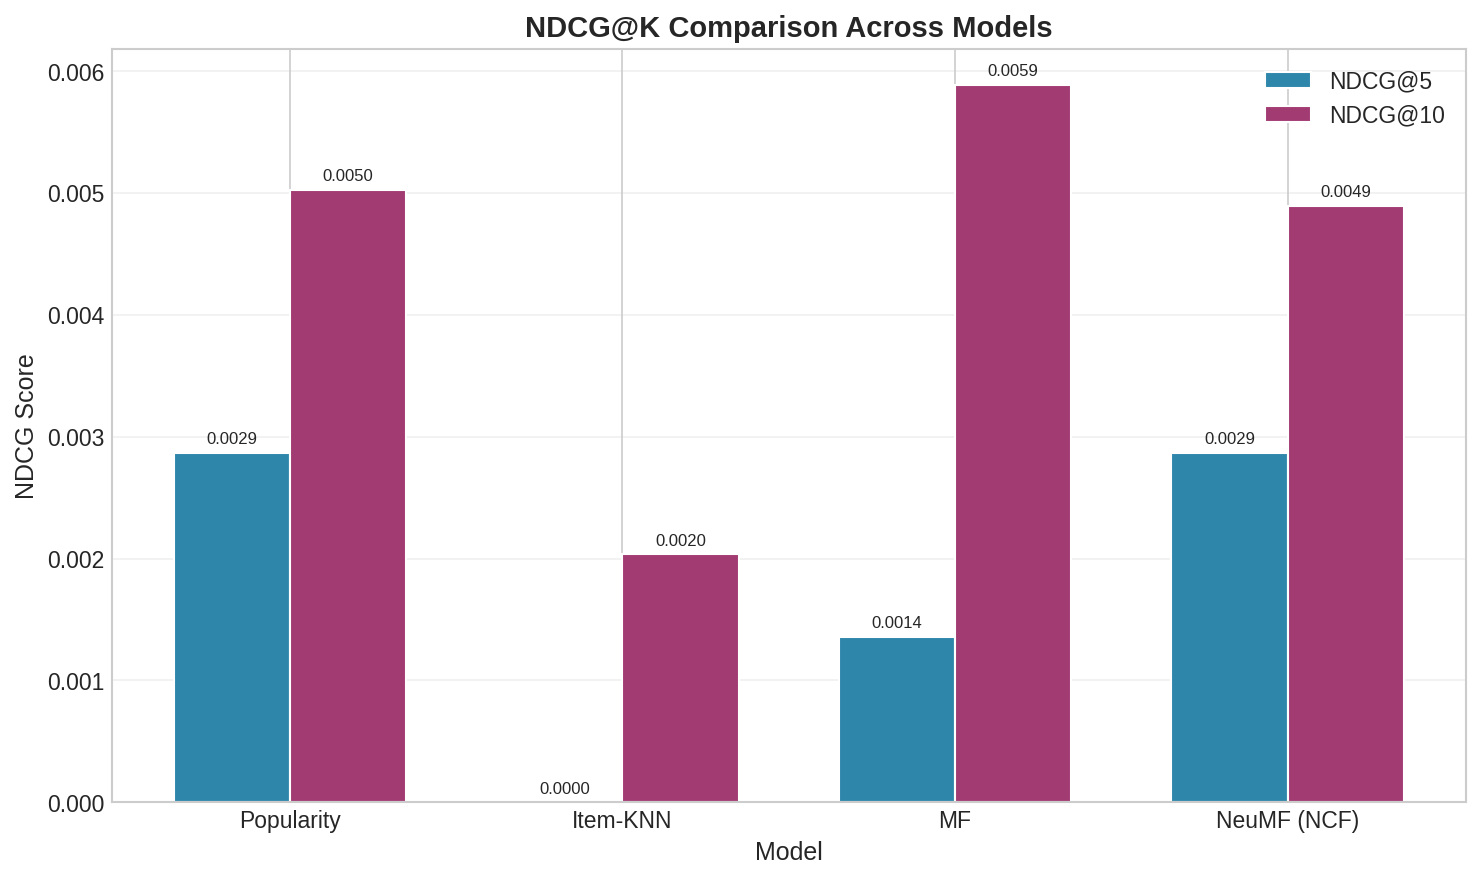

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

models = results_df['Model']
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['NDCG@5'], width, label='NDCG@5', color='#2E86AB', edgecolor='white')
bars2 = ax.bar(x + width/2, results_df['NDCG@10'], width, label='NDCG@10', color='#A23B72', edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('NDCG Score')
ax.set_title('NDCG@K Comparison Across Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_ndcg_comparison.png', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig_ndcg_comparison.pdf', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_ndcg_comparison.png")
plt.show()


 ## 2. Precision-Recall Comparison

Saved: reports/figures/fig_precision_recall.png


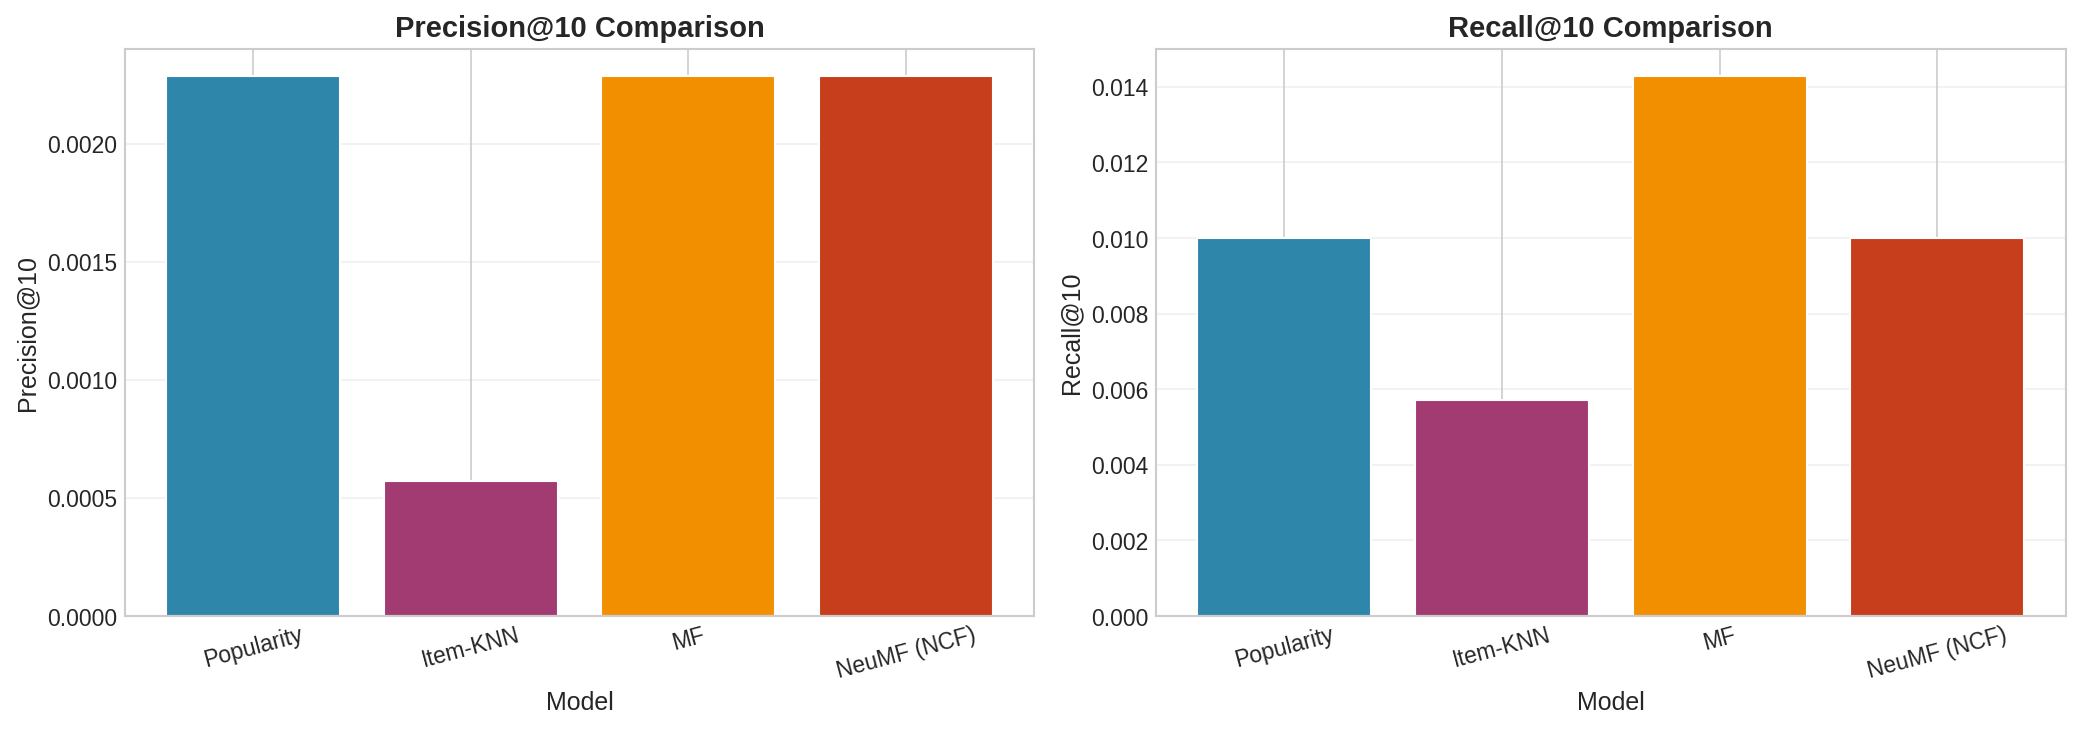

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision
ax = axes[0]
x = np.arange(len(models))
bars = ax.bar(x, results_df['P@10'], color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'], edgecolor='white')
ax.set_xlabel('Model')
ax.set_ylabel('Precision@10')
ax.set_title('Precision@10 Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models.values, rotation=15)
ax.grid(axis='y', alpha=0.3)

# Recall
ax = axes[1]
bars = ax.bar(x, results_df['R@10'], color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'], edgecolor='white')
ax.set_xlabel('Model')
ax.set_ylabel('Recall@10')
ax.set_title('Recall@10 Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models.values, rotation=15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_precision_recall.png', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_precision_recall.png")
plt.show()


 ## 3. Training Time Comparison

Saved: reports/figures/fig_training_time.png


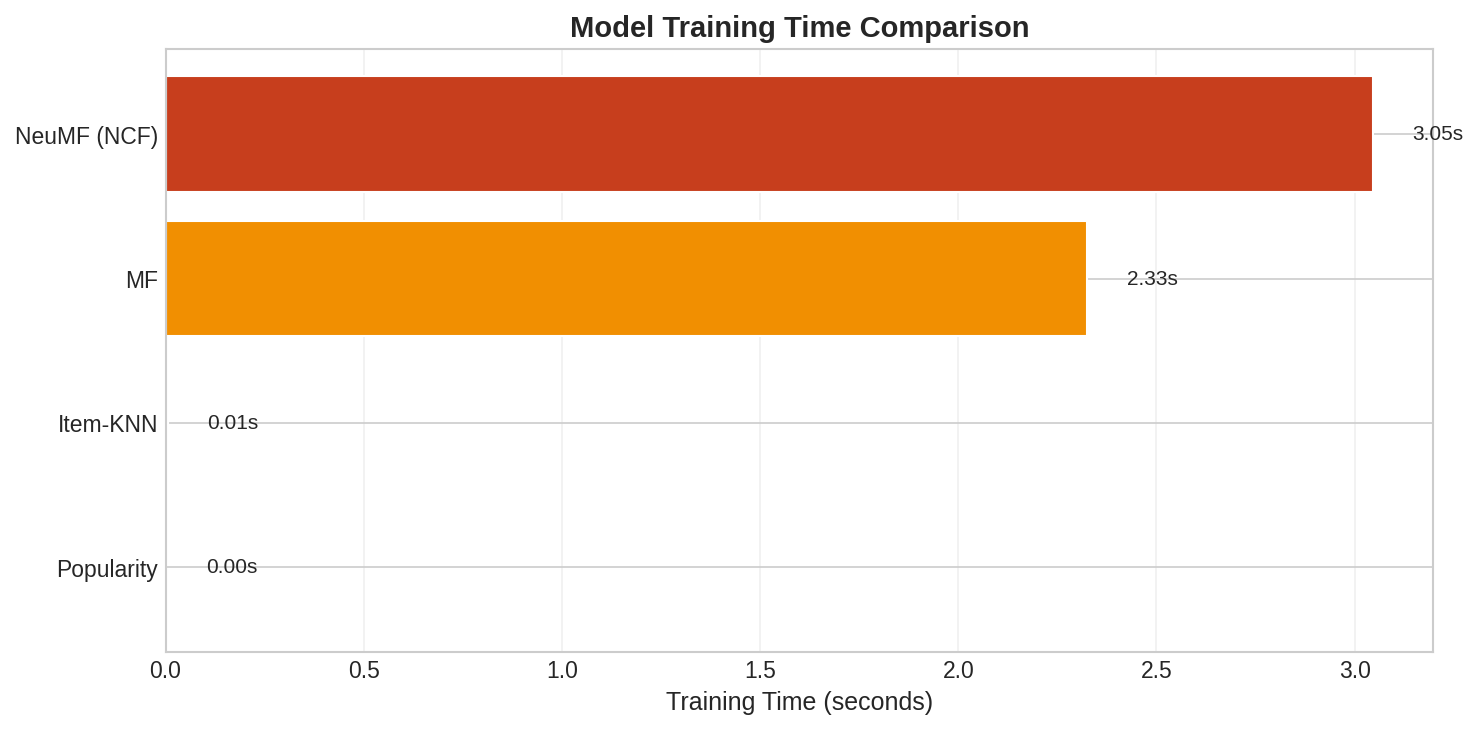

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = ax.barh(models, results_df['Time (s)'], color=colors, edgecolor='white')
ax.set_xlabel('Training Time (seconds)')
ax.set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, results_df['Time (s)']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}s', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_training_time.png', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_training_time.png")
plt.show()


 ## 4. Radar Chart (Multi-Metric Comparison)

Saved: reports/figures/fig_radar_chart.png


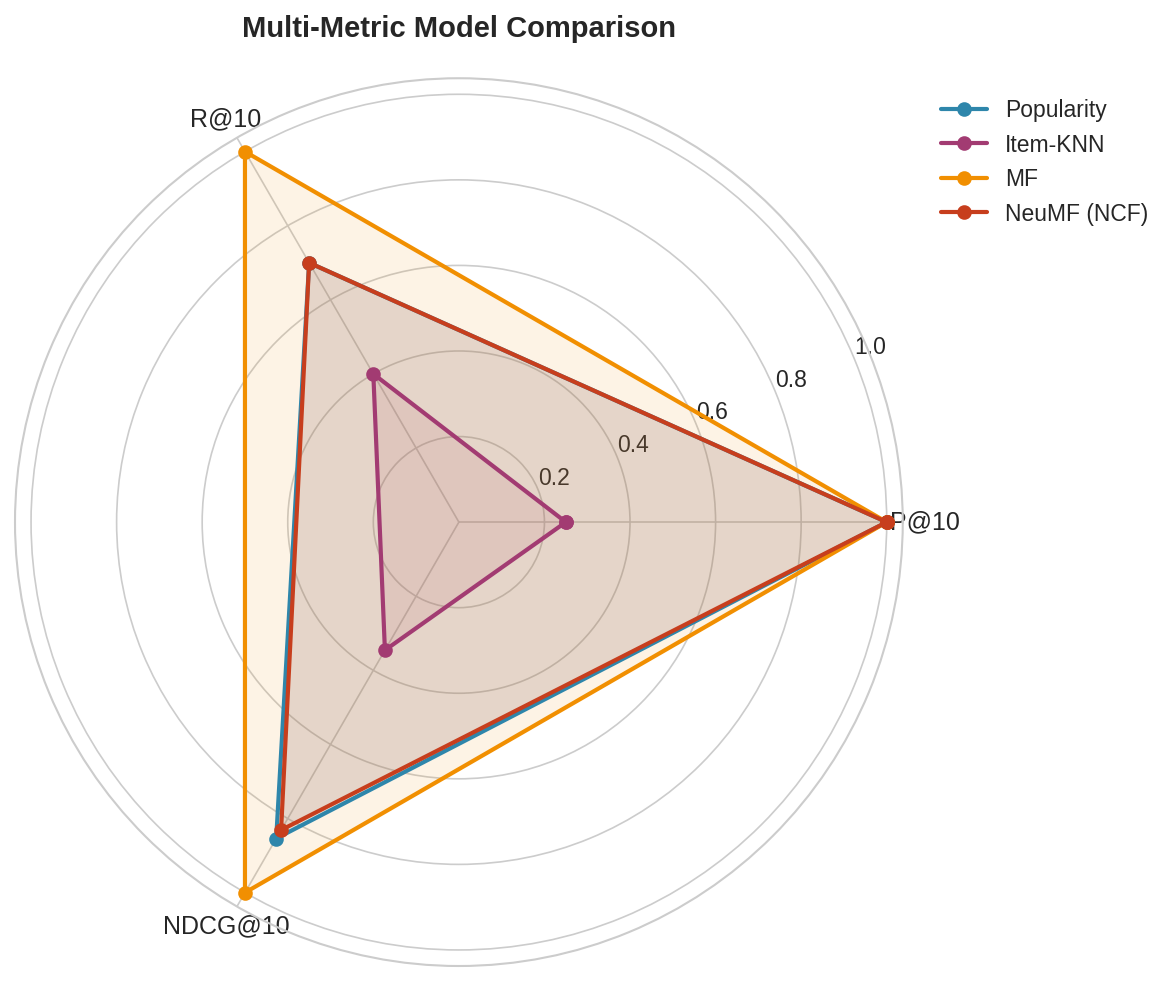

In [13]:
from math import pi

# Normalize metrics for radar chart
metrics = ['P@10', 'R@10', 'NDCG@10']
normalized_df = results_df.copy()
for m in metrics:
    max_val = normalized_df[m].max()
    if max_val > 0:
        normalized_df[m] = normalized_df[m] / max_val

# Number of variables
categories = metrics
N = len(categories)

# Create angles
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
for idx, row in normalized_df.iterrows():
    values = row[metrics].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_title('Multi-Metric Model Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_radar_chart.png', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_radar_chart.png")
plt.show()


 ## Summary

In [14]:
print("\n" + "=" * 60)
print("ALL FIGURES GENERATED")
print("=" * 60)
print(f"Figures saved to: {FIGURES_DIR}/")
print("Files:")
for f in os.listdir(FIGURES_DIR):
    if f.endswith('.png') or f.endswith('.pdf'):
        print(f"  - {f}")



ALL FIGURES GENERATED
Figures saved to: reports/figures/
Files:
  - fig_cold_start.png
  - fig_ablation.png
  - fig_training_loss.png
  - fig_user_activity.pdf
  - fig_training_time.png
  - fig_ndcg_comparison.pdf
  - fig_temporal.png
  - fig_longtail.png
  - fig_model_comparison.png
  - fig_user_activity.png
  - fig_model_comparison.pdf
  - fig_longtail.pdf
  - fig_precision_recall.png
  - fig_ndcg_comparison.png
  - fig_item_popularity.png
  - fig_radar_chart.png
